In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_churn = pd.read_csv("./churn_ecuador_negocios.csv")
df_churn

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,latitud,longitud,Tipo de Negocio
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1,-2.090393,-79.904115,Restaurante
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0,-2.210818,-79.939415,Restaurante
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0,-2.168609,-79.917630,Ferreteria
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,-2.167384,-79.955022,Tienda
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0,-0.173245,-78.469066,Restaurante
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1,-2.221283,-79.913593,Otros
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1,-0.178656,-78.501750,Otros
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1,-0.259370,-78.411662,Farmacia
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1,-0.182831,-78.486435,Restaurante


# Transformación:

In [3]:
scaler = MinMaxScaler(feature_range=(1, 36))
df_churn['Tenure'] = scaler.fit_transform(df_churn[['Tenure']])

In [4]:
df_churn.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,latitud,longitud,Tipo de Negocio
322,323,51,Female,34.220339,21,3,11,Premium,Monthly,471,11,0,-0.112411,-78.459899,Farmacia
63848,63849,32,Female,27.694915,7,7,17,Premium,Annual,598,4,1,-2.875974,-78.971769,Restaurante
7480,7481,49,Male,4.559322,4,8,28,Basic,Monthly,843,13,0,-0.191626,-78.327254,Ferreteria
27885,27886,18,Female,5.745763,4,0,14,Standard,Annual,546,29,0,-0.172147,-78.485675,Restaurante
42332,42333,63,Male,1.000000,13,1,27,Standard,Annual,624,5,0,-0.198543,-78.530415,Restaurante


## Encoding para variables categoricas:

In [5]:
def encode_var(df,variables):

    le_list = []

    for var in variables:
        le = LabelEncoder()
        df[var] = le.fit_transform(df_churn[var])
        le_list.append(le)
    return df, le_list

In [6]:
df_churn, le = encode_var(df_churn,['Gender','Subscription Type','Contract Length','Tipo de Negocio'])

for le_sub in le:
    print(le_sub.classes_)

display(df_churn)

['Female' 'Male']
['Basic' 'Premium' 'Standard']
['Annual' 'Monthly' 'Quarterly']
['Farmacia' 'Ferreteria' 'Otros' 'Restaurante' 'Tienda']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,latitud,longitud,Tipo de Negocio
0,1,22,0,15.237288,14,4,27,0,1,598,9,1,-2.090393,-79.904115,3
1,2,41,0,17.016949,28,7,13,2,1,584,20,0,-2.210818,-79.939415,3
2,3,47,1,16.423729,10,2,29,1,0,757,21,0,-2.168609,-79.917630,1
3,4,35,1,5.745763,12,5,17,1,2,232,18,0,-2.167384,-79.955022,4
4,5,53,0,34.813559,24,9,2,2,0,533,18,0,-0.173245,-78.469066,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,0,19.983051,12,6,21,0,2,947,14,1,-2.221283,-79.913593,2
64370,64371,37,1,3.966102,1,5,22,2,0,923,9,1,-0.178656,-78.501750,2
64371,64372,25,1,23.542373,14,8,30,1,1,327,20,1,-0.259370,-78.411662,0
64372,64373,50,0,11.084746,19,7,22,2,1,540,13,1,-0.182831,-78.486435,3


# Variables de entrenamiento:

In [7]:
Pred_var = 'Churn'
No_test_vars = ['CustomerID', 'Gender',Pred_var]


Y_data_churn = df_churn[Pred_var]
X_data_churn = df_churn.drop(columns=No_test_vars)

display(Y_data_churn.sample(5))
display(X_data_churn.sample(5))

25378    0
22078    0
14902    0
36129    0
34251    1
Name: Churn, dtype: int64

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,latitud,longitud,Tipo de Negocio
56202,44,31.847458,21,7,28,0,1,553,11,-0.332420,-78.506599,3
64087,56,22.355932,7,9,24,1,0,535,25,-2.954679,-79.079563,3
27250,61,31.847458,3,10,19,1,0,515,22,-2.106691,-79.976173,3
47817,33,35.406780,21,10,18,2,0,583,8,-0.244387,-78.423559,3
48323,49,31.847458,30,5,18,0,0,356,26,-2.253542,-79.887885,0


# Feature Selection:

p-value para variables - tomar top 10 mejores; umbral 0.05 o inferior.

In [8]:
# Calculamos ANOVA F-value
f_scores, p_values = f_classif(X_data_churn, Y_data_churn)

# Creamos un DataFrame para ver los resultados claramente
res = pd.DataFrame({
    'Variable': X_data_churn.columns,
    'F_Score': f_scores,
    'p_value': p_values
}).sort_values(by='p_value', ascending=True)

# Normalmente, si el p_value es < 0.05, la relación es estadísticamente significativa

print(res)
best_var = res['Variable'].head(10).tolist()
print(best_var)
X_data_churn_filtrado = X_data_churn[best_var]

             Variable       F_Score        p_value
1              Tenure   2553.385793   0.000000e+00
3       Support Calls   6584.800249   0.000000e+00
4       Payment Delay  29012.627215   0.000000e+00
2     Usage Frequency    864.224640  1.048577e-188
7         Total Spend    402.904012   2.414280e-89
0                 Age    260.260288   1.961525e-58
6     Contract Length     18.823193   1.436306e-05
5   Subscription Type      3.854354   4.962132e-02
11    Tipo de Negocio      3.125389   7.708622e-02
10           longitud      2.903598   8.838688e-02
9             latitud      0.993256   3.189515e-01
8    Last Interaction      0.511200   4.746225e-01
['Tenure', 'Support Calls', 'Payment Delay', 'Usage Frequency', 'Total Spend', 'Age', 'Contract Length', 'Subscription Type', 'Tipo de Negocio', 'longitud']


## Correlacion para verificar colinealidad:

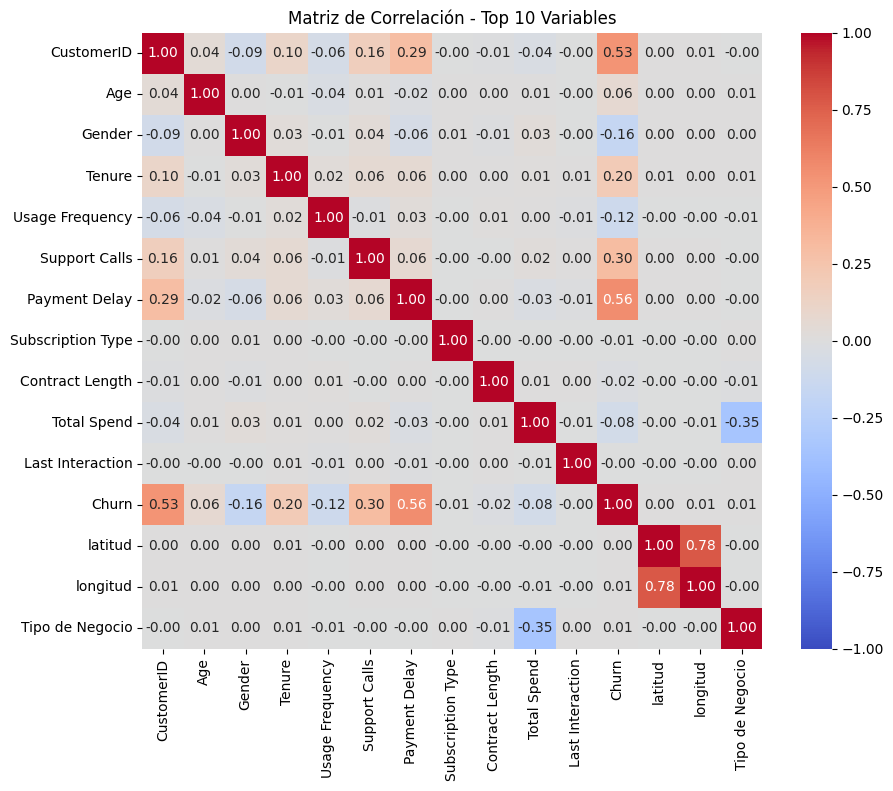

In [13]:
matriz_corr = df_churn.corr()

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generamos un mapa de calor (heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Top 10 Variables")
plt.show()

# Modelado - GVBoost:

In [10]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Calcular el peso para la clase minoritaria (Churn = 1)
conteo_clases = Y_data_churn.value_counts()
peso_positivos = conteo_clases[0] / conteo_clases[1] 

# 2. Configurar StratifiedKFold 
# Nota: Reduje n_splits a 5. Con 10 pliegues y 27 combinaciones, 
# entrenarías 270 modelos, lo que puede tomar mucho tiempo.
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 3. Inicializar el modelo base SOLO con los parámetros fijos
modelo_xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=peso_positivos,
    random_state=42
)

# 4. Crear el diccionario de hiperparámetros a explorar (Grid)
param_grid = {
    'n_estimators': [100, 200, 150, 300],
    'learning_rate': [0.05,0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# 5. Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_xgb_base,
    param_grid=param_grid,
    cv=skf,
    scoring=['roc_auc', 'f1'], # Calculamos ambas métricas
    refit='roc_auc',           # XGBoost elegirá los mejores parámetros basándose en el AUC más alto
    n_jobs=-1,
    verbose=2 # Nivel 2 muestra el progreso de cada combinación
)

# 6. Ejecutar la búsqueda (Esto reemplaza al cross_validate)
print("Iniciando la búsqueda de hiperparámetros...")
grid_search.fit(X_data_churn_filtrado, Y_data_churn)

# 7. Imprimir los resultados globales
print("\n=== Resumen de GridSearchCV ===")
print(f"Mejor configuración de parámetros: {grid_search.best_params_}")
print(f"Mejor ROC-AUC de validación cruzada: {grid_search.best_score_:.4f}")
print(f"F1-Score asociado al mejor modelo: {grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]:.4f}")

# 8. Obtener el modelo definitivo

modelo_optimizado = grid_search.best_estimator_

Iniciando la búsqueda de hiperparámetros...
Fitting 10 folds for each of 48 candidates, totalling 480 fits

=== Resumen de GridSearchCV ===
Mejor configuración de parámetros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Mejor ROC-AUC de validación cruzada: 0.9890
F1-Score asociado al mejor modelo: 0.9525


## Exportar modelo:

In [11]:
from datetime import datetime
import joblib

fecha_str = datetime.now().strftime("%Y_%m_%d_%H_%M")
joblib.dump(modelo_optimizado, 'model_opt_' + fecha_str)

['model_opt_2026_04_19_09_52']

# Explicabilidad de variables basada en el modelo:

c:\Users\bryan\anaconda3\envs\amb_1_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


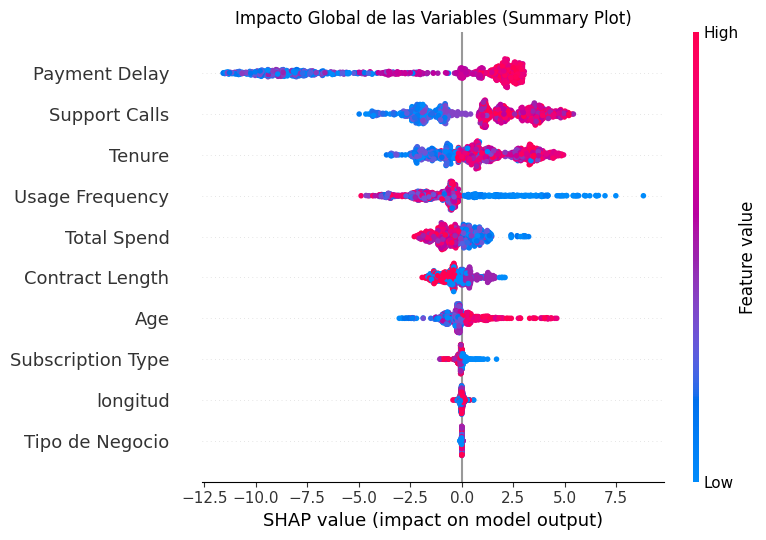

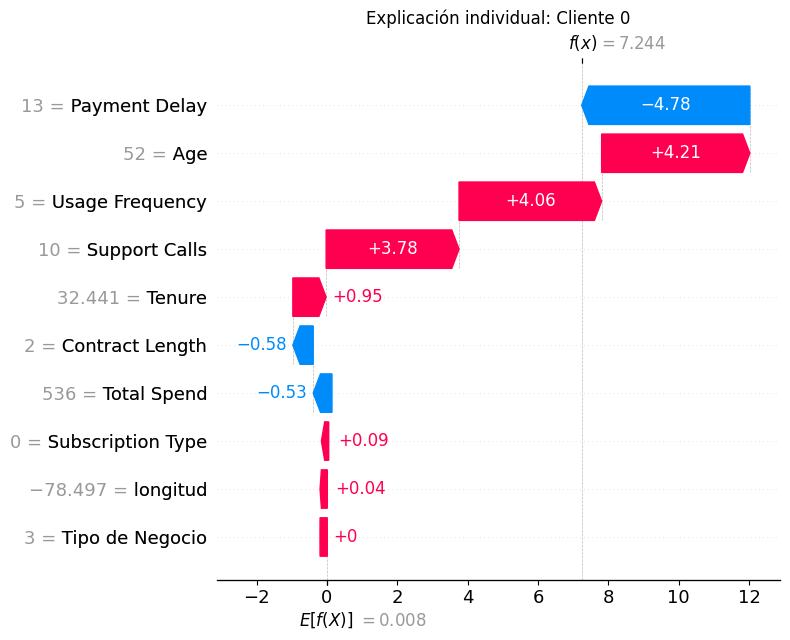

In [12]:
import shap

clientes_aleatorios = X_data_churn_filtrado.sample(1000)
model_booster = modelo_optimizado.get_booster()
explainer = shap.TreeExplainer(model_booster)

# Calculamos los valores SHAP para nuestros datos de prueba
shap_values = explainer.shap_values(clientes_aleatorios)

# --- GRÁFICO 1: Resumen Global (Summary Plot) ---
# Muestra qué variables impactan más y en qué dirección
plt.figure()
plt.title("Impacto Global de las Variables (Summary Plot)")
shap.summary_plot(shap_values, clientes_aleatorios, show=False)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Explicación Local (Waterfall / Force Plot para 1 cliente) ---
# Explicaremos por qué el modelo tomó la decisión para el Cliente #0 del set de prueba
# shap.plots.waterfall requiere un objeto Explanation, así que usamos el explainer general
explainer_obj = shap.Explainer(modelo_optimizado)(clientes_aleatorios)

plt.figure()
shap.plots.waterfall(explainer_obj[0], show=False)
plt.title("Explicación individual: Cliente 0")
plt.tight_layout()
plt.show()

# Agregar Prediccion y probabilidad:

,Tenure,Support Calls,Payment Delay,Usage Frequency,Total Spend,Age,Contract Length,Subscription Type,Tipo de Negocio,longitud
0,15.237288,4,27,14,598,22,1,0,3,-79.904115
1,17.016949,7,13,28,584,41,1,2,3,-79.939415
2,16.423729,2,29,10,757,47,0,1,1,-79.917630
3,5.745763,5,17,12,232,35,2,1,4,-79.955022
4,34.813559,9,2,24,533,53,0,2,3,-78.469066
...,...,...,...,...,...,...,...,...,...,...
64369,19.983051,6,21,12,947,45,2,0,2,-79.913593
64370,3.966102,5,22,1,923,37,0,2,2,-78.501750
64371,23.542373,8,30,14,327,25,1,1,0,-78.411662
64372,11.084746,7,22,19,540,50,1,2,3,-78.486435


In [32]:
df_churn_fin = df_churn.copy()

df_churn_fin['prediccion'] = modelo_optimizado.predict(df_churn_fin[X_data_churn_filtrado.columns.tolist()])

# 'porcentaje_xgboost' tendrá la probabilidad (ej: 0.85 para 85%)
# predict_proba devuelve [prob_clase_0, prob_clase_1], tomamos la segunda columna [:, 1]
df_churn_fin['porcentaje_xgboost'] = modelo_optimizado.predict_proba(df_churn_fin[X_data_churn_filtrado.columns.tolist()])[:, 1]

In [33]:
df_churn_fin['quintil'] = pd.qcut(df_churn_fin['Total Spend'], 5, labels=[5, 4, 3, 2, 1])

In [34]:
df_churn_ori = pd.read_csv("./churn_ecuador_negocios.csv")


In [37]:
df_exportar = pd.merge(
    df_churn_fin, 
    df_churn_ori, 
    on='CustomerID', 
    how='left', 
    suffixes=('_izq', '_der')
)

df_exportar = df_exportar.drop(columns=[col for col in df_exportar.columns if col.endswith('_izq')])

# 2. Quitar el sufijo '_der' de las columnas restantes
df_exportar = df_exportar.rename(columns=lambda x: x.replace('_der', '') if x.endswith('_der') else x)

In [40]:
df_exportar

,CustomerID,prediccion,porcentaje_xgboost,quintil,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,latitud,longitud,Tipo de Negocio
0,1,1,0.793783,3,22,Female,25,14,4,27,Basic,Monthly,598,9,1,-2.090393,-79.904115,Restaurante
1,2,0,0.000035,3,41,Female,28,28,7,13,Standard,Monthly,584,20,0,-2.210818,-79.939415,Restaurante
2,3,0,0.013827,2,47,Male,27,10,2,29,Premium,Annual,757,21,0,-2.168609,-79.917630,Ferreteria
3,4,0,0.001704,5,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,-2.167384,-79.955022,Tienda
4,5,0,0.000325,3,53,Female,58,24,9,2,Standard,Annual,533,18,0,-0.173245,-78.469066,Restaurante
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,1,0.991276,1,45,Female,33,12,6,21,Basic,Quarterly,947,14,1,-2.221283,-79.913593,Otros
64370,64371,1,0.983867,1,37,Male,6,1,5,22,Standard,Annual,923,9,1,-0.178656,-78.501750,Otros
64371,64372,1,0.999816,4,25,Male,39,14,8,30,Premium,Monthly,327,20,1,-0.259370,-78.411662,Farmacia
64372,64373,1,0.769990,3,50,Female,18,19,7,22,Standard,Monthly,540,13,1,-0.182831,-78.486435,Restaurante


In [39]:
df_exportar.to_csv('churn_predicted_xgboost.csv', index=False)